# Resumen Ejecutivo del Análisis de Vinos (Blanco y Tinto)

Este cuaderno contiene el resumen de los análisis realizados luego de aplicar procesos de limpieza y estructuración (Data Wrangling) sobre los datos originales.

Partimos directamente de la base de datos limpia (`datos/procesados/winequality_cleaned.csv`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
%matplotlib inline

# Carga de datos limpios
df = pd.read_csv('../datos/procesados/winequality_cleaned.csv')
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red


## 1. Análisis de Calidad

> **Hallazgo:** La calidad promedio para ambos tipos de vino es de 6. Sin embargo, el vino blanco presenta una concentración proporcionalmente mayor en las puntuaciones altas (7 y 8).

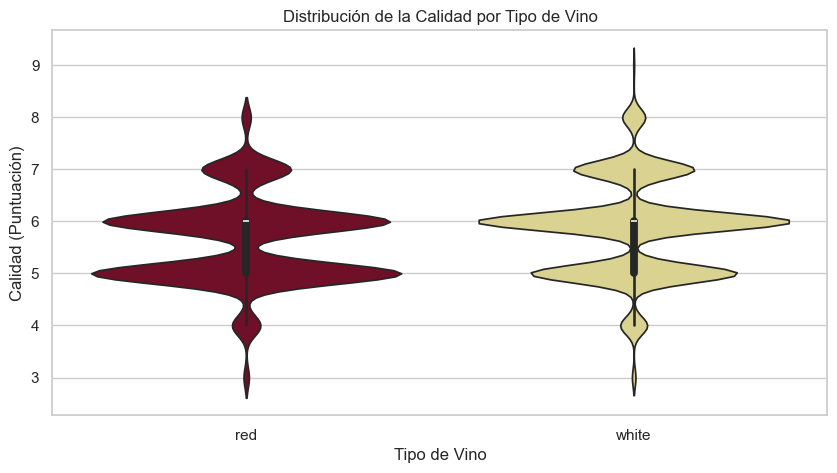

In [2]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='wine_type', y='quality', hue='wine_type', palette={'red': '#800020', 'white': '#e6db85'}, legend=False)
plt.title('Distribución de la Calidad por Tipo de Vino')
plt.xlabel('Tipo de Vino')
plt.ylabel('Calidad (Puntuación)')
plt.show()

## 2. Análisis de Diferencias Químicas (Acidez Volátil y Alcohol)

> **Hallazgo:** El alcohol presenta distribuciones muy similares entre ambos vinos. La verdadera diferencia radica en la **Acidez Volátil**: el vino blanco tiene niveles bajísimos y sumamente controlados para conservar su frescura (el exceso produce sabor a vinagre), mientras que el tinto tolera y presenta niveles significativamente mayores.

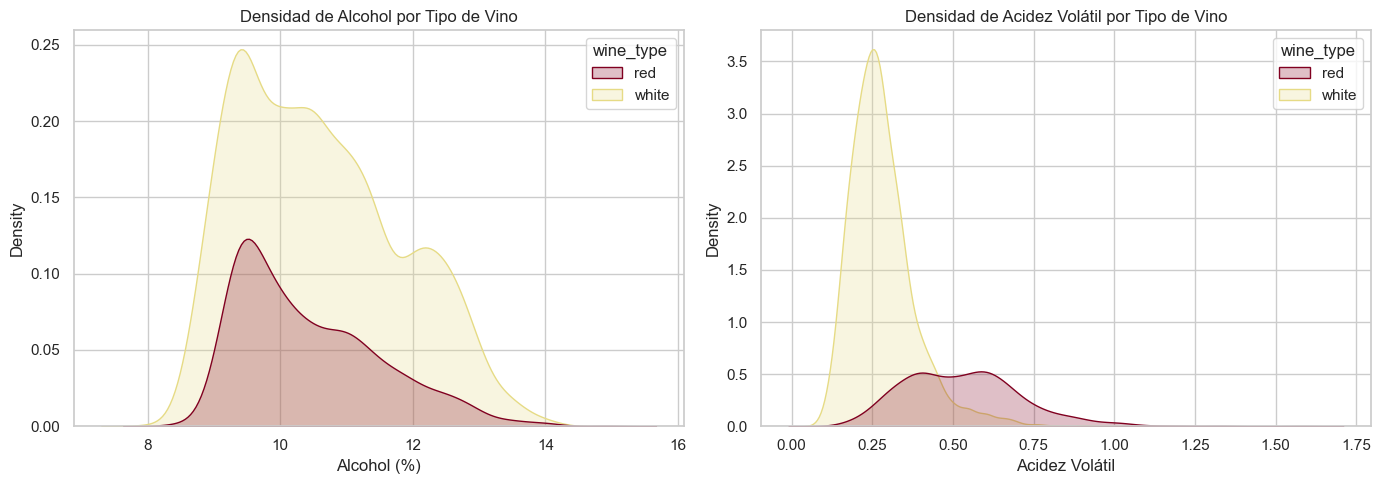

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='alcohol', hue='wine_type', fill=True, palette={'red': '#800020', 'white': '#e6db85'}, ax=axes[0])
axes[0].set_title('Densidad de Alcohol por Tipo de Vino')
axes[0].set_xlabel('Alcohol (%)')

sns.kdeplot(data=df, x='volatile acidity', hue='wine_type', fill=True, palette={'red': '#800020', 'white': '#e6db85'}, ax=axes[1])
axes[1].set_title('Densidad de Acidez Volátil por Tipo de Vino')
axes[1].set_xlabel('Acidez Volátil')

plt.tight_layout()
plt.show()

## 3. Análisis Detallado del Alcohol

> **Hallazgo:** Estadísticamente, el vino blanco tiene una media levísimamente superior (10.59% frente a 10.43%), pero el tinto posee el valor atípico más extremo (14.9%). A pesar de esto, el 50% central de todos los vinos se encuentra en el mismo rango (9.5% a 11.4%), indicando que la industria estandariza el grado alcohólico independientemente del tipo de uva.

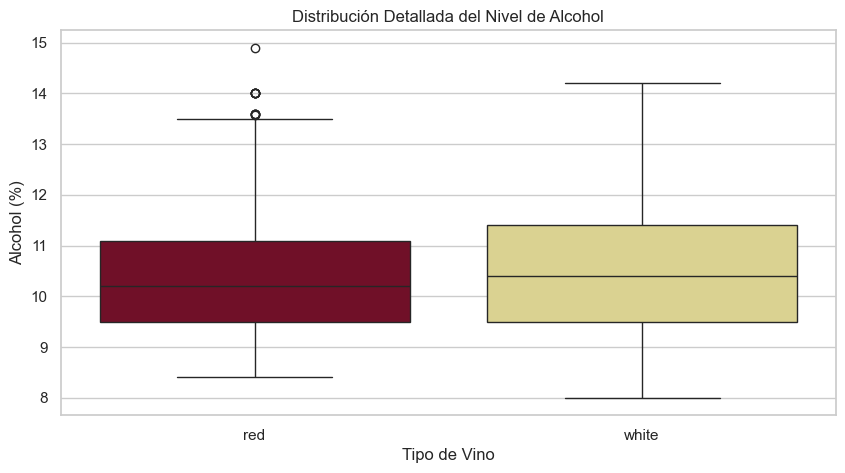

,count,mean,std,min,25%,50%,75%,max
wine_type,,,,,,,,
red,1359.0,10.432315,1.082065,8.4,9.5,10.2,11.1,14.9
white,3961.0,10.589358,1.217076,8.0,9.5,10.4,11.4,14.2


In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='wine_type', y='alcohol', hue='wine_type', palette={'red': '#800020', 'white': '#e6db85'}, legend=False)
plt.title('Distribución Detallada del Nivel de Alcohol')
plt.xlabel('Tipo de Vino')
plt.ylabel('Alcohol (%)')
plt.show()

display(df.groupby('wine_type')['alcohol'].describe())